## Họ và tên: Huỳnh Thế Hy
## Mã sinh viên: 051205009083

In [ ]:
import gymnasium as gym
# 1. Khởi tạo môi trường (render_mode='human' để xem trực quan)
env = gym.make("MountainCar-v0", render_mode="human")

# 2. Reset môi trường
observation, info = env.reset()

for _ in range(1000):
    action = env.action_space.sample()

    # 4. Thực hiện hành động trong môi trường
    observation, reward, terminated, truncated, info = env.step(action)

    # 5. Nếu kết thúc, reset lại môi trường
    if terminated or truncated:
        observation, info = env.reset()

# 6. Đóng môi trường
env.close()

#### Môi trường CartPole

CartPole-V1
Không gian trạng thái: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Không gian hành động: Discrete(2)

Reward trung bình qua 120 episodes: 21.98


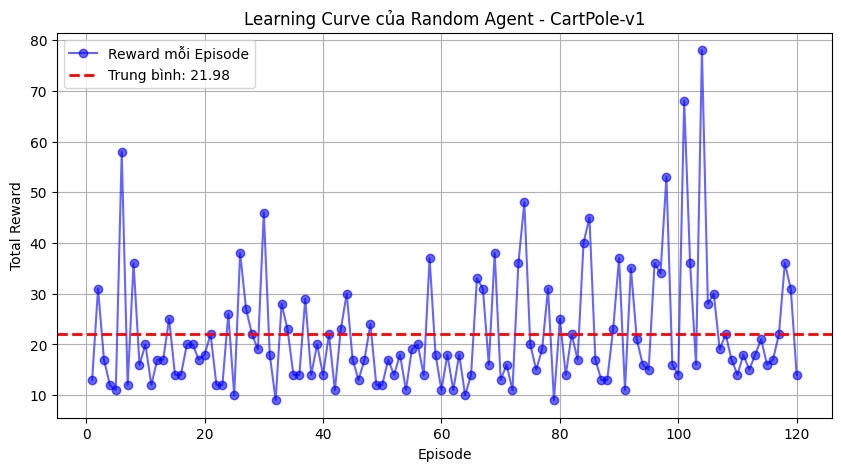

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

env = gym.make("CartPole-v1")
print("CartPole-V1")
print("Không gian trạng thái:", env.observation_space)
print("Không gian hành động:", env.action_space)

so_episodes = 120
danh_sach_rewards = []

for episode in range(so_episodes):
    # Reset môi trường để lấy trạng thái ban đầu
    state, info = env.reset()
    tong_reward = 0
    done = False
    truncated = False
    
    while not (done or truncated):
        # Random agent chọn hành động ngẫu nhiên (0 hoặc 1)
        action = env.action_space.sample()
        
        # Thực hiện hành động
        state, reward, done, truncated, info = env.step(action)
        tong_reward += reward
        
    danh_sach_rewards.append(tong_reward)

env.close()

# Phân tích kết quả
reward_trung_binh = np.mean(danh_sach_rewards)
print(f"\nReward trung bình qua {so_episodes} episodes: {reward_trung_binh:.2f}")

# Vẽ learning curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, so_episodes + 1), danh_sach_rewards, marker='o', linestyle='-', color='b', alpha=0.6, label='Reward mỗi Episode')
plt.axhline(y=reward_trung_binh, color='r', linestyle='--', linewidth=2, label=f'Trung bình: {reward_trung_binh:.2f}')
plt.title('Learning Curve của Random Agent - CartPole-v1')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()

+ Observation có 4 chiều
+ State space là liên tục
+ Action space là rời rạc
+ Reward: +1 cho mỗi bước đi, 0 khi kết thúc episode
+ Episode kết thúc khi:
  - Cột đổ
  - Xe đi quá xa 
  - Hoặc sau 1 số bước đi
+ Reward trung bình tầm 20-25 sau 120 episode.
+ Không có xu hướng tăng theo thời gian.
+ Random agent không hội tụ.
+ cần một policy học được Vì mục tiêu của CartPole là giữ thăng bằng càng lâu càng tốt,  nên ta cần 1 policy hiệu quả để agent biết được cách phả xạ từ state đúng để được được phần thưởng tối đa.

#### môi trường MountainCar

Môi trường MountainCar
Không gian trạng thái: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
Không gian hành động: Discrete(3)

Reward trung bình qua 120 episodes: -200.00


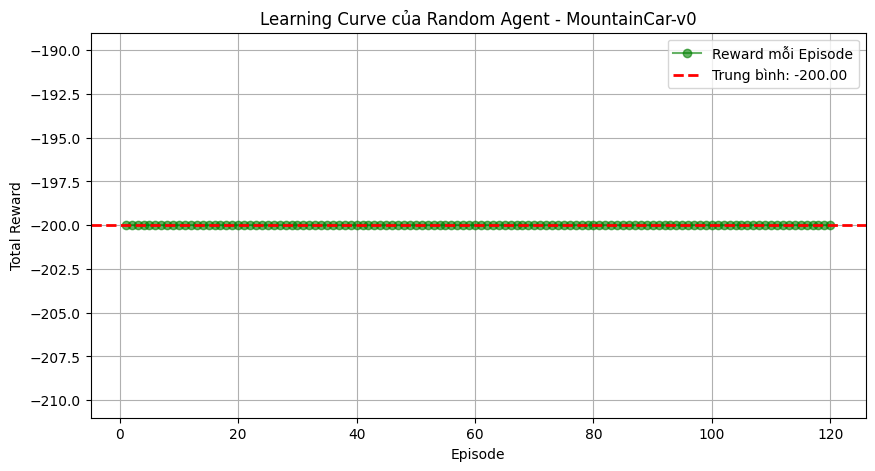

In [3]:
# Khởi tạo môi trường MountainCar
moi_truong_mountaincar = gym.make("MountainCar-v0")
print("Môi trường MountainCar")
print("Không gian trạng thái:", moi_truong_mountaincar.observation_space)
print("Không gian hành động:", moi_truong_mountaincar.action_space)

# Cấu hình số lượng episodes
so_episodes = 120
danh_sach_rewards = []

for episode in range(so_episodes):
    # Reset môi trường để lấy trạng thái ban đầu
    state, info = moi_truong_mountaincar.reset()
    tong_reward = 0
    done = False
    truncated = False
    
    while not (done or truncated):
        # Chọn hành động ngẫu nhiên: 0 (đẩy trái), 1 (không đẩy), 2 (đẩy phải)
        action = moi_truong_mountaincar.action_space.sample()
        
        # Thực hiện hành động
        state, reward, done, truncated, info = moi_truong_mountaincar.step(action)
        tong_reward += reward

    danh_sach_rewards.append(tong_reward)

# Đóng môi trường
moi_truong_mountaincar.close()

# Phân tích kết quả
reward_trung_binh = np.mean(danh_sach_rewards)
print(f"\nReward trung bình qua {so_episodes} episodes: {reward_trung_binh:.2f}")

# Vẽ learning curve
plt.figure(figsize=(10, 5))
plt.plot(range(1, so_episodes + 1), danh_sach_rewards, marker='o', linestyle='-', color='g', alpha=0.6, label='Reward mỗi Episode')
plt.axhline(y=reward_trung_binh, color='r', linestyle='--', linewidth=2, label=f'Trung bình: {reward_trung_binh:.2f}')
plt.title('Learning Curve của Random Agent - MountainCar-v0')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()

+ Observation có 2 chiều
+ State space là liên tục
+ Action space là rời rạc
+ Reward: -1 cho mỗi bước đi, 0 khi kết thúc episode
+ Episode kết thúc khi:
  - chạm được lá cờ
  - sau 200 bước đi mà chưa thành công
+ Reward trung bình -200 sau 120 episode.
+ Không có xu hướng tăng theo thời gian.
+ Random agent không hội tụ.
+ cần một policy học được Vì động cơ của xe không đủ mạnh để leo lên đỉnh núi bên phải để chạm lá cờ. Nên phải lấy đà bằng ngọn núi bên trái và chúng là hành động ngẫu nhiên, nên cần một policy học được để agent biết được cách phả xạ từ state đúng để được được phần thưởng tối đa, xe lên được đỉnh núi.

## MDP & DYNAMIC PROGRAMMING CHO CARTPOLE

4.1
+ CartPole không phải MDP hữu hạn vì không gian trạng thái là BOX là liên tục. Do đó sẽ chứa vô số giá trị nên chúng không được coi là hữu hạn.
+ không thể áp dụng trực tiếp Dynamic Programming vì DP yêu cầu không gian trạng thái là hữu hạn, dựa trên ma trận chuyển đổi xác suất. Với không gian trạng thái là liên tục trên thì không thể lập đươc ma trận để chuyển đổi xác suất được.


4.2 
+ Nếu tăng số bins thì không gian trạng thái sẽ chia nhỏ và nhiều hơn. Điều này giúp cho agnent học được chính xác hơn (đưa ra policy tốt hơn) đồng thời vì không gian trạng thái nhhieeuf hơn nên bắt buộc agent phải mất thời gian nhien hơn.
+ trade-off đọ chính xác và chi phí tính toán:
  - Nếu ưu tiên đọ chính xác cao thì đánh đổi chi phí tính toán cao hơn(tăng số bins và không gian trạng thái sẽ tăng theo cấp số nhân). Số lượng bins nhiều hơn. VÀ NGƯỢC LẠI

4.3
+ Cần ... samples để ước lượng tốt vì...
+ Model ước lượng... chính xác.